<a href="https://colab.research.google.com/github/vashirij/wildfire-tinyml-self-sufficiency/blob/main/Notebooks/03_Active_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 Active Learning for Streaming Wildfire Detection

This notebook implements uncertainty-based active learning, random-sampling comparison, and a fully supervised reference for the simulated wildfire stream.


In [7]:
from pathlib import Path
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Libraries imported successfully.")


Libraries imported successfully.


In [8]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/WildfireProject")
DATA_PATH = PROJECT_ROOT / "data" / "simulated" / "realistic" / "realistic_environment_stream.csv"

ACTIVE_MODEL_DIR = PROJECT_ROOT / "models" / "active_learning"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
PREDICTIONS_DIR = PROJECT_ROOT / "results" / "predictions"
ACTIVE_RESULTS_DIR = PROJECT_ROOT / "results" / "active_learning"
FIGURES_DIR = PROJECT_ROOT / "figures" / "active_learning"

for folder in [ACTIVE_MODEL_DIR, METRICS_DIR, PREDICTIONS_DIR, ACTIVE_RESULTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", DATA_PATH.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset exists: True


In [9]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

FEATURE_COLUMNS = [
    "temperature_c", "humidity_percent", "smoke_ppm", "co_ppm",
    "wind_speed_kmh", "solar_power_w", "battery_voltage"
]
TARGET_COLUMN = "wildfire"

required = ["timestamp", "sample_index", "fire_event_id", TARGET_COLUMN, *FEATURE_COLUMNS]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Dataset shape:", df.shape)
print(df[TARGET_COLUMN].value_counts())
display(df.head())


Dataset shape: (20000, 15)
wildfire
0    14092
1     5908
Name: count, dtype: int64


,timestamp,temperature_c,humidity_percent,smoke_ppm,co_ppm,wind_speed_kmh,solar_power_w,battery_voltage,wildfire,environment_state,fire_phase,fire_severity,fire_event_id,missing_packet,sample_index
0,2026-07-27 00:00:00,13.347181,76.569494,14.397654,0.730587,8.031726,0.0,4.14997,0,sensor_spike,none,0.0,0,False,0
1,2026-07-27 00:00:01,14.356494,64.187253,0.246029,0.580671,6.474338,0.0,4.14994,0,normal,none,0.0,0,False,1
2,2026-07-27 00:00:02,13.320607,85.195248,1.656730,0.937621,7.469129,0.0,4.14991,0,normal,none,0.0,0,False,2
3,2026-07-27 00:00:03,14.112753,68.244563,2.435927,0.366247,8.917727,0.0,4.14988,0,normal,none,0.0,0,False,3
4,2026-07-27 00:00:04,14.849696,67.837010,0.279561,1.479401,7.423717,0.0,4.14985,0,normal,none,0.0,0,False,4


In [10]:
INITIAL_LABELED_FRACTION = 0.20
FINAL_TEST_FRACTION_OF_REMAINDER = 0.20
MAX_QUERY_LABELS = 250
RETRAIN_BATCH_SIZE = 25
UNCERTAINTY_THRESHOLD = 0.30

initial_end = int(len(df) * INITIAL_LABELED_FRACTION)
initial_df = df.iloc[:initial_end].copy()
remaining_df = df.iloc[initial_end:].copy()

final_test_size = int(len(remaining_df) * FINAL_TEST_FRACTION_OF_REMAINDER)
stream_df = remaining_df.iloc[:-final_test_size].copy()
final_test_df = remaining_df.iloc[-final_test_size:].copy()

if initial_df[TARGET_COLUMN].nunique() < 2:
    raise ValueError("Initial partition contains only one class.")
if final_test_df[TARGET_COLUMN].nunique() < 2:
    raise ValueError("Final test partition contains only one class.")

X_initial = initial_df[FEATURE_COLUMNS].copy()
y_initial = initial_df[TARGET_COLUMN].astype(int).copy()
X_final_test = final_test_df[FEATURE_COLUMNS].copy()
y_final_test = final_test_df[TARGET_COLUMN].astype(int).copy()

print("Initial:", len(initial_df), "Stream:", len(stream_df), "Final test:", len(final_test_df))


Initial: 4000 Stream: 12800 Final test: 3200


In [11]:
def create_model(seed=SEED):
    return RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

def false_alarm_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) else 0.0

def evaluate(name, model, X, y, labels_used):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1_score": f1_score(y, pred, zero_division=0),
        "false_alarm_rate": false_alarm_rate(y, pred),
        "labels_used": int(labels_used),
        "predictions": pred,
        "probabilities": prob
    }


In [12]:
initial_model = create_model()
initial_model.fit(X_initial, y_initial)

initial_eval = evaluate(
    "Initial Seed Model",
    initial_model,
    X_final_test,
    y_final_test,
    len(y_initial)
)

print({k: v for k, v in initial_eval.items() if k not in ["predictions", "probabilities"]})


{'model': 'Initial Seed Model', 'accuracy': 0.7165625, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0, 'false_alarm_rate': np.float64(0.0), 'labels_used': 4000}


In [13]:
def run_active_learning():
    model = create_model()
    model.fit(X_initial, y_initial)

    labeled_X = X_initial.reset_index(drop=True).copy()
    labeled_y = y_initial.reset_index(drop=True).copy()

    pending_X, pending_y = [], []
    queried, stream_records, curve = [], [], []
    total_queries = 0
    retraining_round = 0

    for pos, (_, row) in enumerate(stream_df.iterrows()):
        sample = pd.DataFrame([row[FEATURE_COLUMNS].to_dict()], columns=FEATURE_COLUMNS)
        probs = model.predict_proba(sample)[0]
        pred = int(np.argmax(probs))
        uncertainty = float(1 - np.max(probs))
        true_label = int(row[TARGET_COLUMN])

        query = uncertainty >= UNCERTAINTY_THRESHOLD and total_queries < MAX_QUERY_LABELS

        if query:
            pending_X.append(row[FEATURE_COLUMNS].to_dict())
            pending_y.append(true_label)
            total_queries += 1
            queried.append({
                "timestamp": row["timestamp"],
                "sample_index": int(row["sample_index"]) if pd.notna(row["sample_index"]) else -1,
                "fire_event_id": int(row["fire_event_id"]) if pd.notna(row["fire_event_id"]) else -1,
                "true_label": true_label,
                "predicted_label_before_query": pred,
                "fire_probability": float(probs[1]),
                "uncertainty": uncertainty,
                "stream_position": pos
            })

        stream_records.append({
            "timestamp": row["timestamp"],
            "sample_index": int(row["sample_index"]) if pd.notna(row["sample_index"]) else -1,
            "fire_event_id": int(row["fire_event_id"]) if pd.notna(row["fire_event_id"]) else -1,
            "true_label": true_label,
            "predicted_label": pred,
            "fire_probability": float(probs[1]),
            "uncertainty": uncertainty,
            "query_requested": query,
            "total_queries": total_queries,
            "retraining_round": retraining_round
        })

        if len(pending_y) >= RETRAIN_BATCH_SIZE:
            labeled_X = pd.concat(
                [labeled_X, pd.DataFrame(pending_X, columns=FEATURE_COLUMNS)],
                ignore_index=True
            )
            labeled_y = pd.concat(
                [labeled_y, pd.Series(pending_y, dtype=int)],
                ignore_index=True
            )

            retraining_round += 1
            model = create_model(SEED + retraining_round)
            model.fit(labeled_X, labeled_y)

            curve.append({
                "stream_position": pos,
                "retraining_round": retraining_round,
                "total_queries": total_queries,
                "total_labeled_samples": len(labeled_y)
            })
            pending_X, pending_y = [], []

    if pending_y:
        labeled_X = pd.concat(
            [labeled_X, pd.DataFrame(pending_X, columns=FEATURE_COLUMNS)],
            ignore_index=True
        )
        labeled_y = pd.concat(
            [labeled_y, pd.Series(pending_y, dtype=int)],
            ignore_index=True
        )
        retraining_round += 1
        model = create_model(SEED + retraining_round)
        model.fit(labeled_X, labeled_y)

    return {
        "model": model,
        "queried": pd.DataFrame(queried),
        "stream": pd.DataFrame(stream_records),
        "curve": pd.DataFrame(curve),
        "total_queries": total_queries,
        "total_labeled_samples": len(labeled_y),
        "retraining_rounds": retraining_round
    }

active = run_active_learning()
active_model = active["model"]

print("Queries:", active["total_queries"])
print("Retraining rounds:", active["retraining_rounds"])
display(active["queried"].head())

Queries: 250
Retraining rounds: 10


,timestamp,sample_index,fire_event_id,true_label,predicted_label_before_query,fire_probability,uncertainty,stream_position
0,2026-07-27 01:11:07,4267,5,1,0,0.332585,0.332585,267
1,2026-07-27 01:11:15,4275,5,1,0,0.303229,0.303229,275
2,2026-07-27 01:11:16,4276,5,1,0,0.339252,0.339252,276
3,2026-07-27 01:11:18,4278,5,1,0,0.311593,0.311593,278
4,2026-07-27 01:11:22,4282,5,1,0,0.307792,0.307792,282


In [14]:
active_eval = evaluate(
    "Uncertainty Active Learning",
    active_model,
    X_final_test,
    y_final_test,
    active["total_labeled_samples"]
)

rng = np.random.default_rng(SEED)
query_count = min(active["total_queries"], len(stream_df))
positions = np.sort(rng.choice(len(stream_df), size=query_count, replace=False))
random_rows = stream_df.iloc[positions].copy()

random_X = pd.concat([X_initial, random_rows[FEATURE_COLUMNS]], ignore_index=True)
random_y = pd.concat(
    [y_initial, random_rows[TARGET_COLUMN].astype(int)],
    ignore_index=True
)

random_model = create_model(SEED + 100)
random_model.fit(random_X, random_y)
random_eval = evaluate(
    "Random Sampling",
    random_model,
    X_final_test,
    y_final_test,
    len(random_y)
)

full_X = pd.concat([X_initial, stream_df[FEATURE_COLUMNS]], ignore_index=True)
full_y = pd.concat(
    [y_initial, stream_df[TARGET_COLUMN].astype(int)],
    ignore_index=True
)

full_model = create_model(SEED + 200)
full_model.fit(full_X, full_y)
full_eval = evaluate(
    "Fully Supervised Reference",
    full_model,
    X_final_test,
    y_final_test,
    len(full_y)
)

def row(e):
    return {k: v for k, v in e.items() if k not in ["predictions", "probabilities"]}

comparison_df = pd.DataFrame([
    row(initial_eval),
    row(random_eval),
    row(active_eval),
    row(full_eval)
])

comparison_df["label_fraction"] = comparison_df["labels_used"] / len(full_y)
comparison_df["label_savings"] = 1 - comparison_df["label_fraction"]

display(comparison_df.round(4))


,model,accuracy,precision,recall,f1_score,false_alarm_rate,labels_used,label_fraction,label_savings
0,Initial Seed Model,0.7166,0.0000,0.0000,0.0000,0.0000,4000,0.2381,0.7619
1,Random Sampling,0.9250,0.8829,0.8479,0.8650,0.0445,4250,0.2530,0.7470
2,Uncertainty Active Learning,0.9106,0.8272,0.8655,0.8459,0.0715,4250,0.2530,0.7470
3,Fully Supervised Reference,0.8756,0.7223,0.9118,0.8060,0.1387,16800,1.0000,0.0000


In [15]:
comparison_path = METRICS_DIR / "week3_active_learning_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

active["queried"].to_csv(
    ACTIVE_RESULTS_DIR / "week3_uncertainty_queried_samples.csv",
    index=False
)
active["stream"].to_csv(
    PREDICTIONS_DIR / "week3_active_learning_stream.csv",
    index=False
)
active["curve"].to_csv(
    ACTIVE_RESULTS_DIR / "week3_learning_curve.csv",
    index=False
)
random_rows[["timestamp", "sample_index", "fire_event_id", TARGET_COLUMN]].to_csv(
    ACTIVE_RESULTS_DIR / "week3_random_queried_samples.csv",
    index=False
)

final_predictions = final_test_df[
    ["timestamp", "sample_index", "fire_event_id", TARGET_COLUMN]
].copy()
final_predictions["initial_prediction"] = initial_eval["predictions"]
final_predictions["random_prediction"] = random_eval["predictions"]
final_predictions["active_prediction"] = active_eval["predictions"]
final_predictions["fully_supervised_prediction"] = full_eval["predictions"]
final_predictions.to_csv(
    PREDICTIONS_DIR / "week3_final_test_predictions.csv",
    index=False
)

joblib.dump(active_model, ACTIVE_MODEL_DIR / "uncertainty_active_learning.joblib")
joblib.dump(random_model, ACTIVE_MODEL_DIR / "random_sampling.joblib")
joblib.dump(full_model, ACTIVE_MODEL_DIR / "fully_supervised_reference.joblib")

print("Outputs saved successfully.")


Outputs saved successfully.


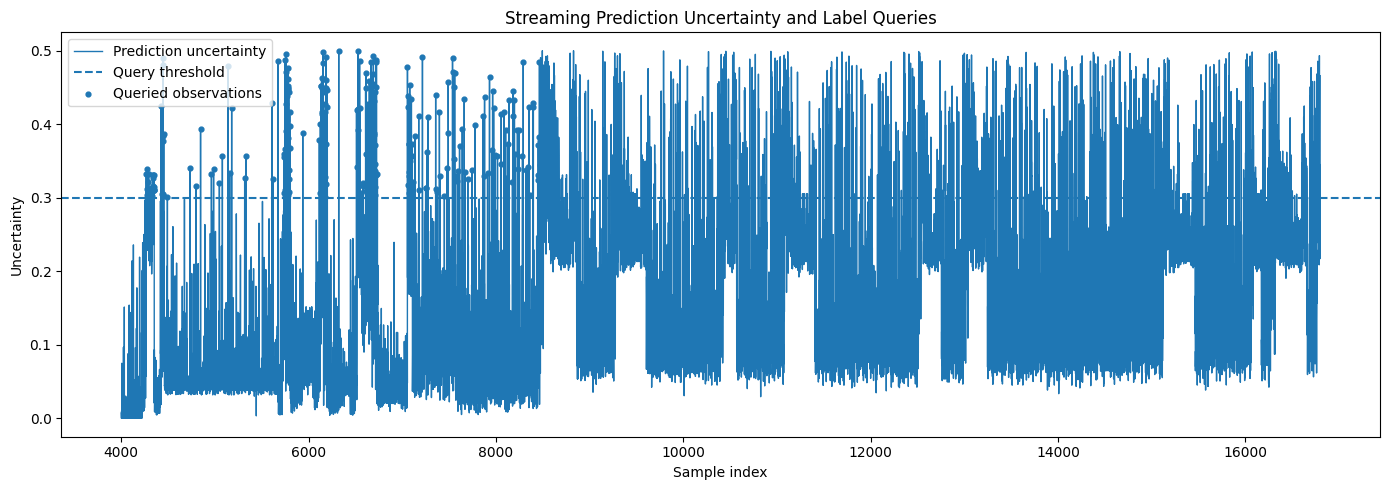

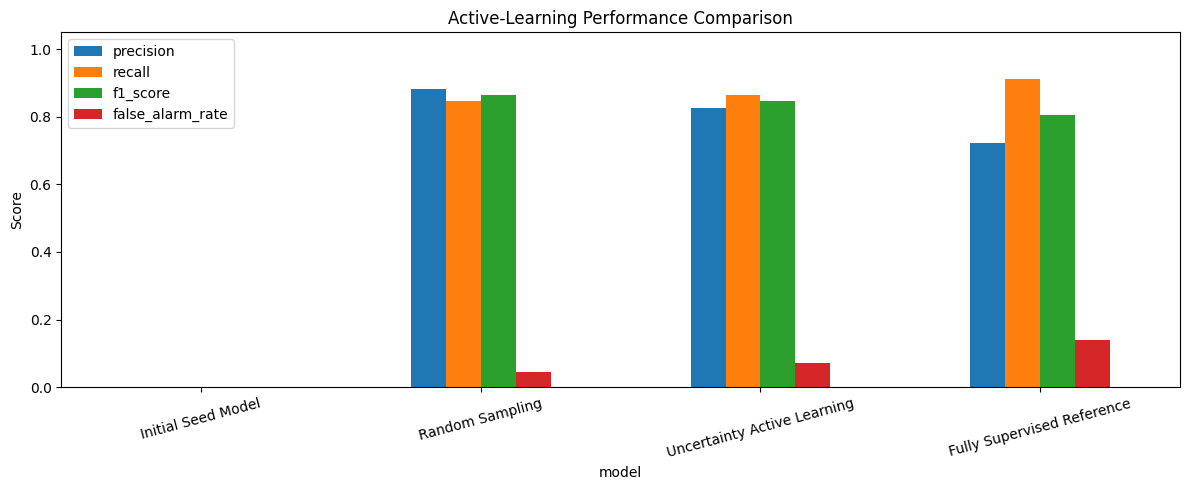

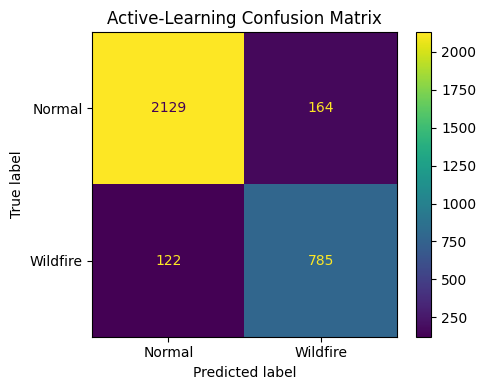

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(
    active["stream"]["sample_index"],
    active["stream"]["uncertainty"],
    linewidth=1,
    label="Prediction uncertainty"
)
plt.axhline(
    UNCERTAINTY_THRESHOLD,
    linestyle="--",
    label="Query threshold"
)
mask = active["stream"]["query_requested"]
plt.scatter(
    active["stream"].loc[mask, "sample_index"],
    active["stream"].loc[mask, "uncertainty"],
    s=12,
    label="Queried observations"
)
plt.xlabel("Sample index")
plt.ylabel("Uncertainty")
plt.title("Streaming Prediction Uncertainty and Label Queries")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "stream_uncertainty_queries.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

ax = comparison_df.set_index("model")[
    ["precision", "recall", "f1_score", "false_alarm_rate"]
].plot(kind="bar", figsize=(12, 5))
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Active-Learning Performance Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "active_learning_performance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_final_test,
    active_eval["predictions"],
    display_labels=["Normal", "Wildfire"],
    values_format="d",
    ax=ax
)
ax.set_title("Active-Learning Confusion Matrix")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "active_learning_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
active_row = comparison_df[
    comparison_df["model"] == "Uncertainty Active Learning"
].iloc[0]

summary_df = pd.DataFrame([{
    "initial_labeled_samples": len(y_initial),
    "stream_samples": len(stream_df),
    "final_test_samples": len(final_test_df),
    "queried_labels": active["total_queries"],
    "total_labels_used": int(active_row["labels_used"]),
    "label_savings": active_row["label_savings"],
    "retraining_rounds": active["retraining_rounds"],
    "accuracy": active_row["accuracy"],
    "precision": active_row["precision"],
    "recall": active_row["recall"],
    "f1_score": active_row["f1_score"],
    "false_alarm_rate": active_row["false_alarm_rate"]
}])

summary_path = ACTIVE_RESULTS_DIR / "week3_active_learning_summary.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df.round(4))

print("=" * 70)
print("ACTIVE-LEARNING EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 70)
print("Queried labels:", active["total_queries"])
print("Label savings:", f"{active_row['label_savings']:.2%}")
print("Recall:", round(active_row["recall"], 4))
print("F1-score:", round(active_row["f1_score"], 4))


In [18]:
print(FEATURE_COLUMNS)

['temperature_c', 'humidity_percent', 'smoke_ppm', 'co_ppm', 'wind_speed_kmh', 'solar_power_w', 'battery_voltage']


In [19]:
display(
    df.groupby("wildfire")[FEATURE_COLUMNS]
      .describe()
)

temperature_c                                                       \
                 count       mean       std       min        25%        50%   
wildfire                                                                      
0              14092.0  16.030163  3.388427  5.427413  13.623378  15.807202   
1               5908.0  21.211484  5.326992  7.793304  17.504707  20.523746   

                               humidity_percent             ... solar_power_w  \
                75%        max            count       mean  ...           75%   
wildfire                                                    ...                 
0         18.273528  37.542037          14092.0  71.612032  ...           0.0   
1         24.020355  44.306963           5908.0  64.602250  ...           0.0   

              battery_voltage                                          \
          max           count      mean       std       min       25%   
wildfire                                                                
0         0.0         14092.0  3.649772  0.296214  3.200000  3.425292   
1         0.0          5908.0  3.647366  0.282096  3.199949  3.380069   

                                        
               50%       75%       max  
wildfire                                
0         3.626045  3.930526  4.149970  
1         3.663220  3.868344  4.131801  

[2 rows x 56 columns]

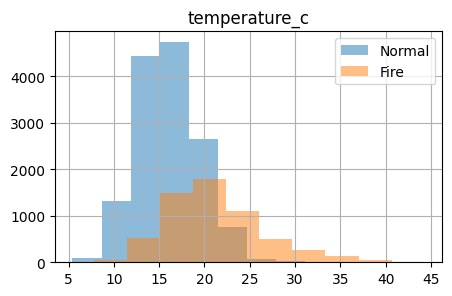

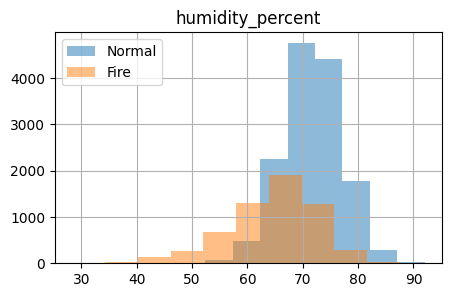

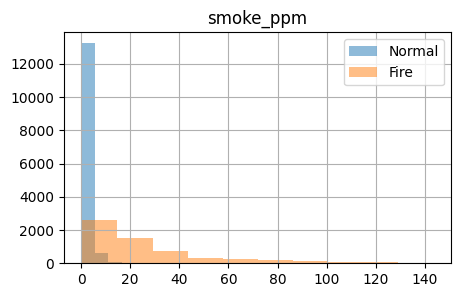

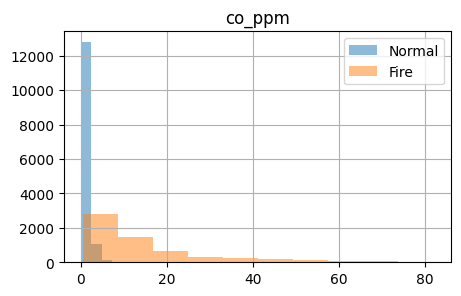

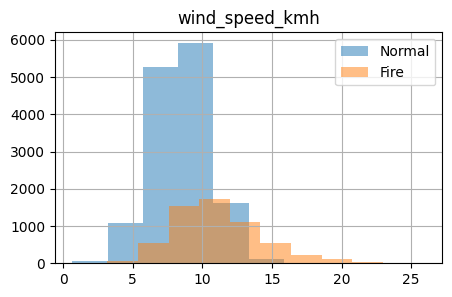

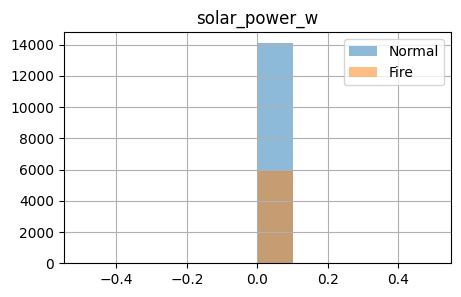

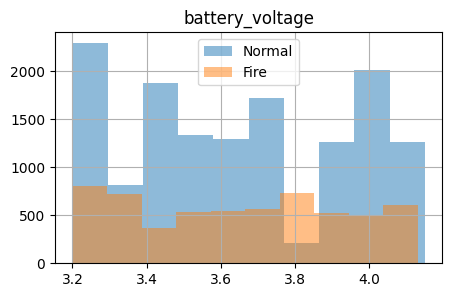

In [20]:
import matplotlib.pyplot as plt

for feature in FEATURE_COLUMNS:
    plt.figure(figsize=(5,3))
    df[df["wildfire"]==0][feature].hist(alpha=0.5, label="Normal")
    df[df["wildfire"]==1][feature].hist(alpha=0.5, label="Fire")
    plt.title(feature)
    plt.legend()
    plt.show()

In [21]:
print(initial_df.head())
print(final_test_df.head())

            timestamp  temperature_c  humidity_percent  smoke_ppm    co_ppm  \
0 2026-07-27 00:00:00      13.347181         76.569494  14.397654  0.730587   
1 2026-07-27 00:00:01      14.356494         64.187253   0.246029  0.580671   
2 2026-07-27 00:00:02      13.320607         85.195248   1.656730  0.937621   
3 2026-07-27 00:00:03      14.112753         68.244563   2.435927  0.366247   
4 2026-07-27 00:00:04      14.849696         67.837010   0.279561  1.479401   

   wind_speed_kmh  solar_power_w  battery_voltage  wildfire environment_state  \
0        8.031726            0.0          4.14997         0      sensor_spike   
1        6.474338            0.0          4.14994         0            normal   
2        7.469129            0.0          4.14991         0            normal   
3        8.917727            0.0          4.14988         0            normal   
4        7.423717            0.0          4.14985         0            normal   

  fire_phase  fire_severity  fire_even